# 01 - Comprensión de los datos y análisis exploratorio de datos

Este cuaderno explora las variables seleccionadas del conjunto de datos de la Encuesta sobre Cultura Política. 

El objetivo es comprender la estructura de los datos, evaluar los valores perdidos, analizar la variable objetivo P5328 y justificar la transformación de la escala ideológica en un problema de clasificación binaria.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
from pathlib import Path

In [20]:
BASE_DIR = Path.cwd().parent

In [33]:
matplotlib inline

------------------------------------

In [42]:
DATA_PATH = BASE_DIR / "data" / "raw" / "empalme_politica.csv"

data = pd.read_csv(DATA_PATH)

print("Original dataset shape:", data.shape)

data.head()

Original dataset shape: (64759, 420)


,DIRECTORIO,NRO_ENCUESTA,HOGAR_NUMERO,PERSONA_NUMERO,P606,P2057,P2059,P2061,P2063,P2063S3,...,P2051S2,P2051S3,P2051S4,P2051S5,P2051S6,P2051S7,P2051S8,P2051S9,P2051S10,P2051S11
0,112214,252,1,1,6.0,2.0,2.0,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,112214,252,1,2,4.0,2.0,2.0,2.0,1.0,NaN,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,112214,252,1,3,1.0,2.0,2.0,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,112214,252,1,4,1.0,2.0,2.0,2.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,112214,252,1,5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Selección columnas del proyecto

In [43]:
columnas = [
    "P220",
    "P2057",
    "P605",
    "P6210",
    "P6945",
    "P3039",
    "P2001S1",
    "P2001S2",
    "P2001S3",
    "P2001S4",
    "P2001S17",
    "P2001S7",
    "P2001S12",
    "P2001S13",
    "P2001S14",
    "P2001S15",
    "P2001S18",
    "P2003S4",
    "P2001S10",
    "P2003S17",
    "P2003S7",
    "P2003S10",
    "P2003S12",
    "P2003S13",
    "P2003S14",
    "P2003S15",
    "P2003S18",
    "P5373S4",
    "P5373S5",
    "P5373S6",
    "P5306S1",
    "P5306S2",
    "P2019",
    "P2016S1",
    "P2016S2",
    "P2016S3",
    "P2016S4",
    "P2016S5",
    "P2016S6",
    "P2016S7",
    "P2016S8",
    "P2016S9",
    "P2017S1",
    "P2017S2",
    "P2017S3",
    "P2017S4",
    "P2017S5",
    "P2017S6",
    "P2021",
    "P1754",
    "P5376S1",
    "P5376S2",
    "P5376S3",
    "P5376S4",
    "P5376S5",
    "P5376S6",
    "P5317S4",
    "P5317S5",
    "P5307S1",
    "P5307S2",
    "P5307S3",
    "P5307S4",
    "P5307S5",
    "P2017S7",
    "P5314S2",
    "P5314S3",
    "P5314S4",
    "P5314S5",
    "P5314S6",
    "P5314S7",
    "P5317S1",
    "P5317S9",
    "P2009S9",
    "P5328"
]

In [44]:
empalme_poli_tica = data[columnas].copy()

print("Selected dataset shape:", empalme_poli_tica.shape)

empalme_poli_tica.head()

Selected dataset shape: (64759, 74)


,P220,P2057,P605,P6210,P6945,P3039,P2001S1,P2001S2,P2001S3,P2001S4,...,P5314S2,P5314S3,P5314S4,P5314S5,P5314S6,P5314S7,P5317S1,P5317S9,P2009S9,P5328
0,1,2.0,3.0,6.0,1.0,1.0,2.0,2.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0
1,2,2.0,3.0,5.0,1.0,2.0,2.0,2.0,2.0,2.0,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0
2,2,2.0,2.0,6.0,1.0,2.0,2.0,2.0,2.0,2.0,...,1.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,5.0
3,1,2.0,1.0,5.0,1.0,1.0,2.0,2.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,6.0
4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Perfil del conjunto de datos

Se generó un informe de perfil para obtener una visión general de las variables seleccionadas, incluyendo distribuciones, valores perdidos y correlaciones.

In [45]:
profile = ProfileReport(
    empalme_poli_tica,
    title="Dataset política",
    explorative=True
)

profile.to_file("../figures/data_profile_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Algunas variables pueden estar correlacionadas porque capturan dimensiones similares del comportamiento político, como percepción institucional, corrupción, confianza, religión o actitudes sociales. En esta etapa exploratoria se conservan inicialmente, y su contribución predictiva será evaluada posteriormente mediante el desempeño de los modelos y técnicas de interpretabilidad.

## 2. Valores NaN

In [25]:
missing_values = empalme_poli_tica.isna().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

P605       18367
P6945      18367
P6210      18367
P2057      18296
P3039      18296
           ...  
P5314S7    18296
P5317S1    18296
P5317S9    18296
P2009S9    18296
P5328      18296
Length: 73, dtype: int64

In [47]:
missing_summary = pd.DataFrame({
    "Missing Count":empalme_poli_tica.isna().sum(),
    "Missing Percentage":(
        empalme_poli_tica.isna().sum()/len(empalme_poli_tica)
    )*100
})

missing_summary = missing_summary[
    missing_summary["Missing Count"]>0
]

missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
P605,18367,28.362081
P6945,18367,28.362081
P6210,18367,28.362081
P2057,18296,28.252444
P3039,18296,28.252444
...,...,...
P5314S7,18296,28.252444
P5317S1,18296,28.252444
P5317S9,18296,28.252444
P2009S9,18296,28.252444


El análisis de los valores perdidos reveló que aproximadamente el 28 % de las observaciones contenían información incompleta en un gran número de variables, incluida la variable objetivo (P5328).

Dado que la falta de datos afectaba simultáneamente a la mayoría de las variables predictoras y a la variable objetivo, la imputación podría introducir patrones artificiales y sesgos en la tarea de clasificación.

Por este motivo, se optó por el análisis de casos completos (dropna) para conservar únicamente las observaciones con información completa.

In [26]:
print("="*50)

cantidad_datos = len(empalme_poli_tica)

print(f"Cantidad de datos: {cantidad_datos}")

print("="*50)

cantidad_no_nulos = len(empalme_poli_tica.dropna())

print(f"Cantidad de datos no nulos: {cantidad_no_nulos}")

print("="*50)

porcentaje_eliminado = ((cantidad_datos - cantidad_no_nulos) / cantidad_datos) * 100

print(f"Porcentaje de datos eliminados si se aplica dropna: {porcentaje_eliminado:.2f}%")

Cantidad de datos: 64759
Cantidad de datos no nulos: 46392
Porcentaje de datos eliminados si se aplica dropna: 28.36%


## 3. Análisis de la variable objetivo

La variable P5328 representa la autolocalización ideológica en una escala política izquierda-derecha. Esta variable se utilizará como variable objetivo para la tarea de clasificación.

In [27]:
empalme_poli_tica["P5328"].value_counts().sort_index()

P5328
1.0      1985
2.0       689
3.0      1661
4.0      1911
5.0     16901
6.0      2727
7.0      1895
8.0      1990
9.0      1012
10.0     5263
98.0     5877
99.0     4552
Name: count, dtype: int64

In [28]:
target_percentages = (
    empalme_poli_tica["P5328"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_percentages

P5328
1.0      4.272217
2.0      1.482900
3.0      3.574888
4.0      4.112950
5.0     36.375180
6.0      5.869186
7.0      4.078514
8.0      4.282978
9.0      2.178077
10.0    11.327293
98.0    12.648774
99.0     9.797043
Name: proportion, dtype: float64

## 4. Porcentaje de “no sabe” y “no informa”

In [29]:
cantidad_total = len(empalme_poli_tica)

porcentaje_no_sabe = (
    empalme_poli_tica["P5328"].tolist().count(99) 
    / cantidad_total * 100
)

porcentaje_no_informa = (
    empalme_poli_tica["P5328"].tolist().count(98) 
    / cantidad_total * 100
)

print(f"Porcentaje de no sabe: {porcentaje_no_sabe:.2f}%")
print(f"Porcentaje de no informa: {porcentaje_no_informa:.2f}%")

Porcentaje de no sabe: 7.03%
Porcentaje de no informa: 9.08%


## 5. Histograma original de P5328

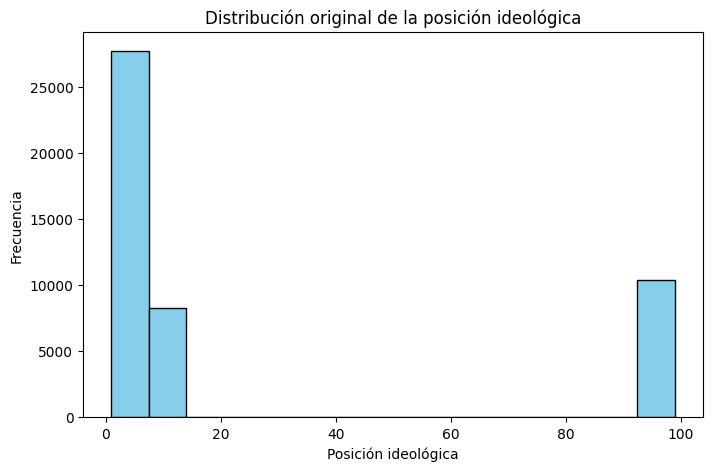

In [35]:
plt.figure(figsize=(8, 5))

plt.hist(
    empalme_poli_tica["P5328"],
    bins=15,
    color="skyblue",
    edgecolor="black"
)


plt.xlabel("Posición ideológica")
plt.ylabel("Frecuencia")
plt.title("Distribución original de la posición ideológica")

plt.savefig(BASE_DIR / "figures" / "distribucionOgPosicionIdeologica.png", dpi=300, bbox_inches="tight")

plt.show()

## 6. Criterio del Barómetro de las Américas

El análisis se centra en identificar los factores asociados a la orientación política izquierda-derecha. Siguiendo la escala ideológica izquierda-derecha utilizada en estudios sobre comportamiento político, como el Barómetro de las Américas, la variable P5328 se agrupará en dos categorías:

- Izquierda: valores del 1 al 4.
- Derecha: valores del 7 al 10.

Se excluirán los valores centrales 5 y 6, ya que representan posiciones ideológicas moderadas o ambiguas.

También se excluirán los valores 98 y 99, ya que corresponden a categorías de falta de respuesta.

![Americas Barometer ideological scale](../figures/americas_barometer_scale.png)

## 7. Simulación de limpieza

In [36]:
target_analysis = empalme_poli_tica.copy()

target_analysis = target_analysis[
    ~target_analysis["P5328"].isin([98, 99])
]

target_analysis = target_analysis[
    ~target_analysis["P5328"].isin([5, 6])
]

print(target_analysis["P5328"].value_counts().sort_index())

P5328
1.0     1985
2.0      689
3.0     1661
4.0     1911
7.0     1895
8.0     1990
9.0     1012
10.0    5263
Name: count, dtype: int64


## 8. Histograma sin categorías no válidas ni centrales

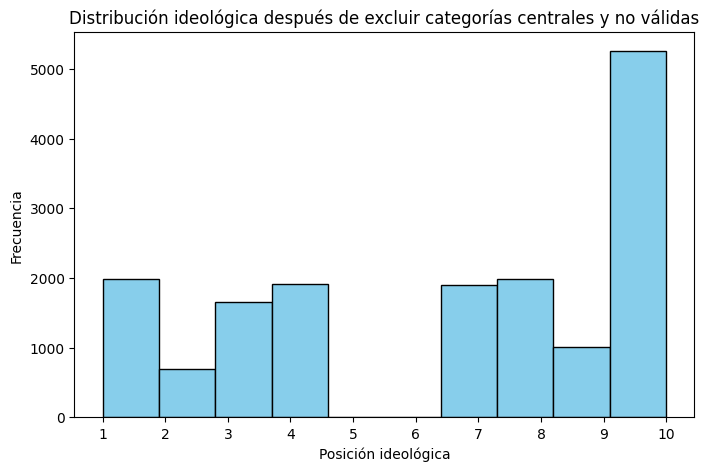

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(
    target_analysis["P5328"],
    bins=10,
    color="skyblue",
    edgecolor="black"
)

plt.xticks(range(1, 11))

plt.xlabel("Posición ideológica")
plt.ylabel("Frecuencia")
plt.title("Distribución ideológica después de excluir categorías centrales y no válidas")

plt.savefig(BASE_DIR / "figures" / "distribucionIdeologicaSinCentralesNoValidas.png", dpi=300, bbox_inches="tight")

plt.show()

## 9. Transformación binaria exploratoria

In [39]:
target_analysis["orientation_binary"] = np.where(
    target_analysis["P5328"] <= 4,
    0,
    1
)

target_analysis["orientation_binary"].value_counts()

orientation_binary
1    28456
0     6246
Name: count, dtype: int64

## 10. Izquierda vs derecha

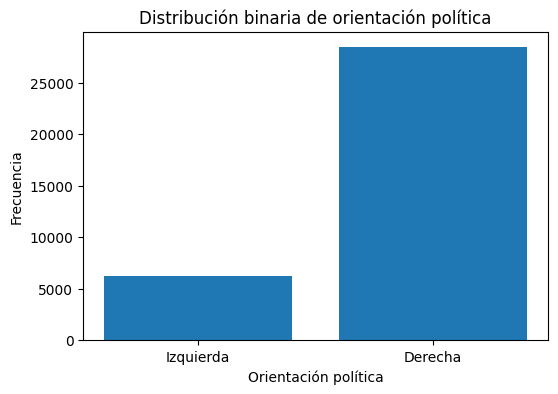

In [40]:
categorias = ["Izquierda", "Derecha"]

valores = [
    target_analysis[target_analysis["orientation_binary"] == 0].shape[0],
    target_analysis[target_analysis["orientation_binary"] == 1].shape[0]
]

plt.figure(figsize=(6, 4))

plt.bar(categorias, valores)

plt.xlabel("Orientación política")
plt.ylabel("Frecuencia")
plt.title("Distribución binaria de orientación política")

plt.savefig(BASE_DIR / "figures"/ "distribucibinariaOrientaciPoltica.png", dpi=300, bbox_inches="tight")

plt.show()

In [41]:
(
    target_analysis["orientation_binary"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

orientation_binary
0    17.998963
1    82.001037
Name: proportion, dtype: float64

## 11. Conclusiones del análisis exploratorio

El análisis exploratorio ha revelado que el conjunto de datos seleccionado contiene valores perdidos que deben tratarse antes de entrenar el modelo. La variable de destino P5328 incluye valores válidos de la escala ideológica, categorías centrales y categorías de falta de respuesta.

A partir de este análisis, en el siguiente cuaderno se aplicarán las siguientes decisiones de preprocesamiento:

- Eliminar las observaciones con valores perdidos.
- Eliminar los valores 98 y 99 de P5328, ya que representan categorías de falta de respuesta.
- Eliminar los valores 5 y 6 de P5328, ya que representan posiciones ideológicas centrales o ambiguas.
- Transformar P5328 en una variable objetivo binaria:
  - 0: encuestados de orientación izquierdista.
  - 1: encuestados de orientación derechista.

Estas decisiones permiten formular la tarea como un problema de clasificación binaria.